In [ ]:
from drausp_env import get_instance_data, get_env, register_env
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14.8     |
|    ep_rew_mean      | 470      |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1530     |
|    time_elapsed     | 0        |
|    total_timesteps  | 59       |
----------------------------------


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment DRAUSP already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13.9     |
|    ep_rew_mean      | 478      |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 363      |
|    time_elapsed     | 0        |
|    total_timesteps  | 111      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 35.4     |
|    n_updates        | 2        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13.2     |
|    ep_rew_mean      | 484      |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 414      |
|    time_elapsed     | 0        |
|    total_timesteps  | 159      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 28.4     |
|    n_updates      

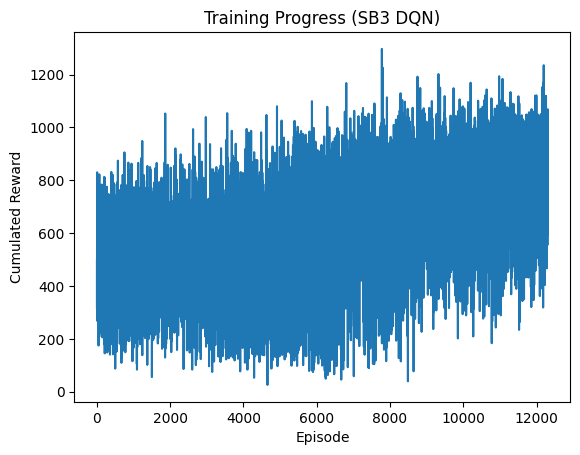

In [4]:
from pathlib import Path
data_path = Path("../instances/lion18s/SA01.txt")
instance_data = get_instance_data(data_path, 20)
env_id = register_env(instance_data)
drausp_env = get_env(env_id, 1)

# Callback der die Rewards speichert
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True

# Training mit bestehender env
callback = RewardCallback()
model = DQN("MlpPolicy", drausp_env, verbose=1, exploration_fraction=0.4, exploration_final_eps=0.05)
model.learn(total_timesteps=200_000, log_interval=4)
# Plot
plt.plot(callback.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress (SB3 DQN)")
plt.show()
